# 실습) 차량동영상에서 번호판 문자 인식


### 요구사항
1. 영상 에 보여지는 복수개의 차량번호판 인식하기
1. 출력 요소
    1. 차량번호판으로 인식이 된 영역(들)을 사각형으로 표시
    1. 인식한 차량번호판(들)의 글자 표시
    
    
1. 중간에 'ESC' 를 누르면 종료하게 하기    
    

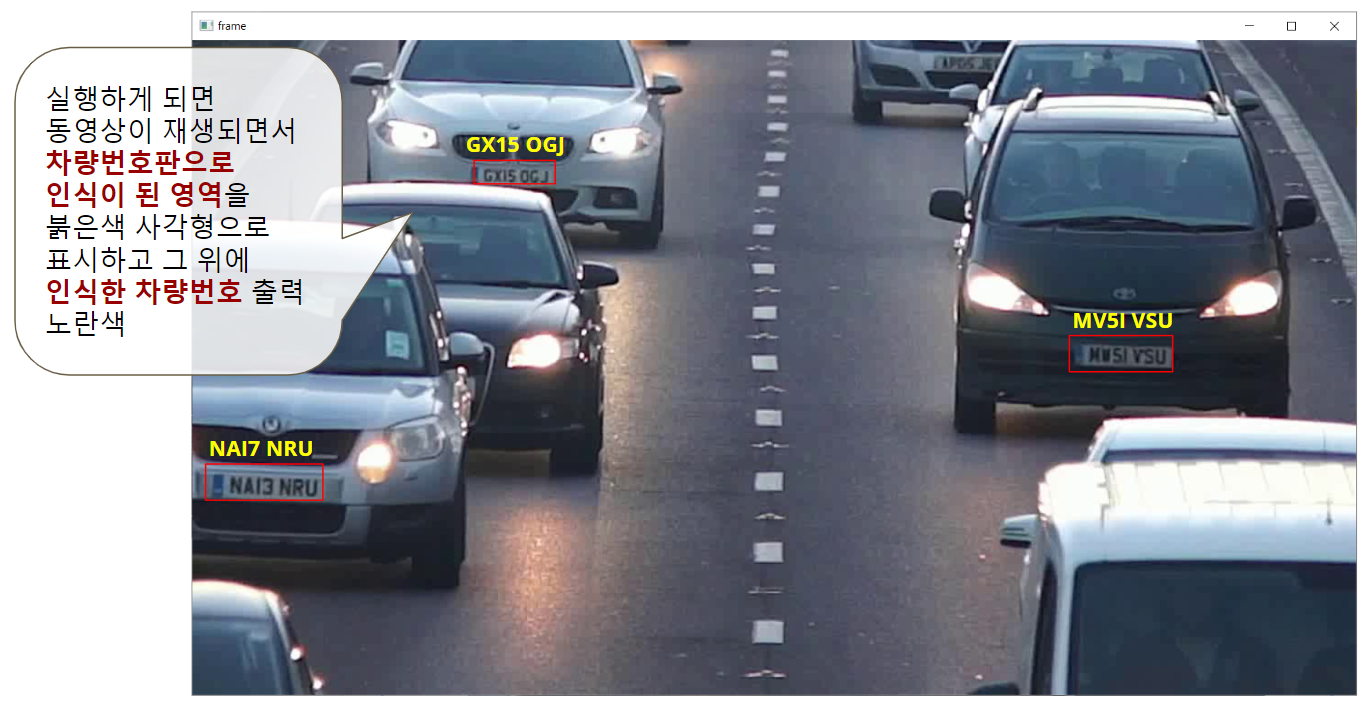

### 파일
- carplate2.mp4  (영상파일)
- carplate2.py   (최종 작성 파일)


### 작성및 제출
- OpenCV 와 pytesseract 를 사용
- 최대한 정확 + 속도 인식하도록 코드를 구성하고 작성 해보기
    - 참고) tesseract 문자인식 하는 부분가 가장 시간이 많이 걸린다.  어케 하면 최적화 할것인가?

- 다양한 실험은 배포된 노트북 파일등을 활용하고
- 최종적인 결과코드는 **carplate2.py** 파일에 완성해놓습니다.
- 명령행에서 **>python carplate2.py**  로 실행되는것 확인하시고 저장하세요

### 기타
- 동영상 원본 출처 : https://www.pexels.com/ko-kr/video/2103099/
    - 따로 다운받진 마시고, 수정하여 배포된 영상으로 실습 진행하세요
 
- tessetact에 추가적인 언어 데이터는 사용하지 마세요.

# import

In [16]:
import os, re, sys, time

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    # macOS에서는 destroyAllWindows()만으로는 창이 안 닫히고, 뒤에 waitKey(1)을 몇 번 더 때려줘야 실제로 사라짐
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True, figsize=(14, 8)):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()        

In [17]:
# base_path = r'D:\KDT2604\dataset\ComputerVision\carplate2'
base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/carplate2"
video_path = os.path.join(base_path, 'carplate2.mp4')
video_path

'/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/carplate2/carplate2.mp4'

# 원본 영상

width: 1280 height: 720
fps: 30.0 delay: 33
(720, 1280, 3)


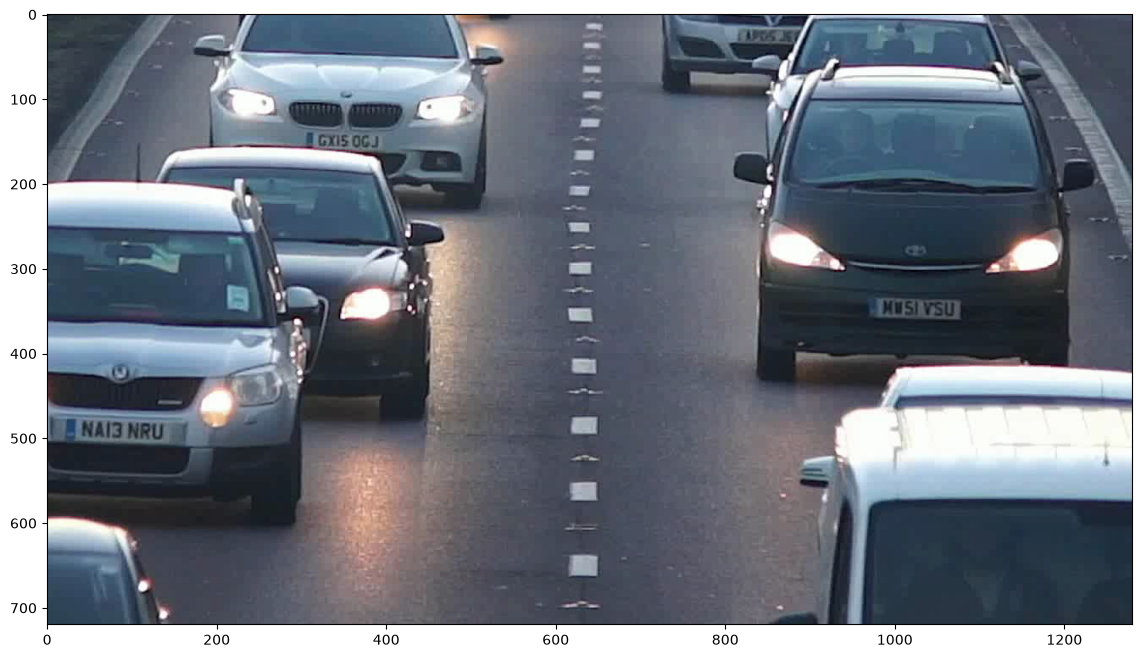

In [18]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print('영상을 열 수 없습니다')
else:
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    delay = int(1000 / fps)

    print('width:', w, 'height:', h)
    print('fps:', fps, 'delay:', delay)

    _, frame = cap.read()
    
    cap.release()

    print(frame.shape)
    plt_imshow(frame)

# GrayScale 영상

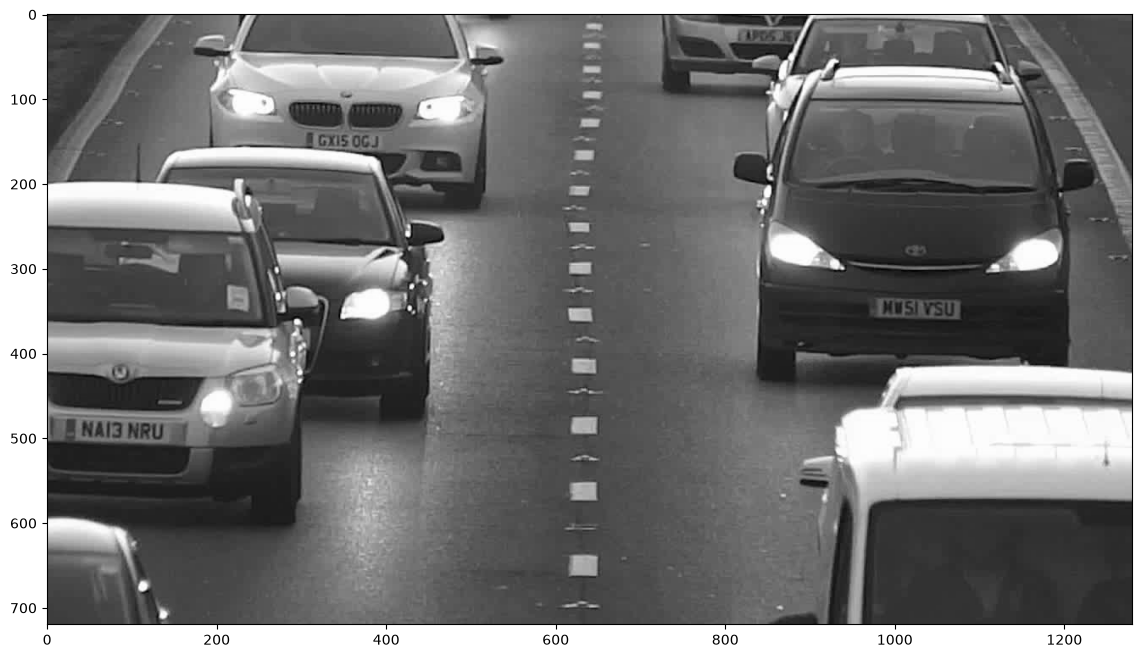

In [19]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

plt_imshow(gray)

# Gaussian Blur and Adaptive Thresholding

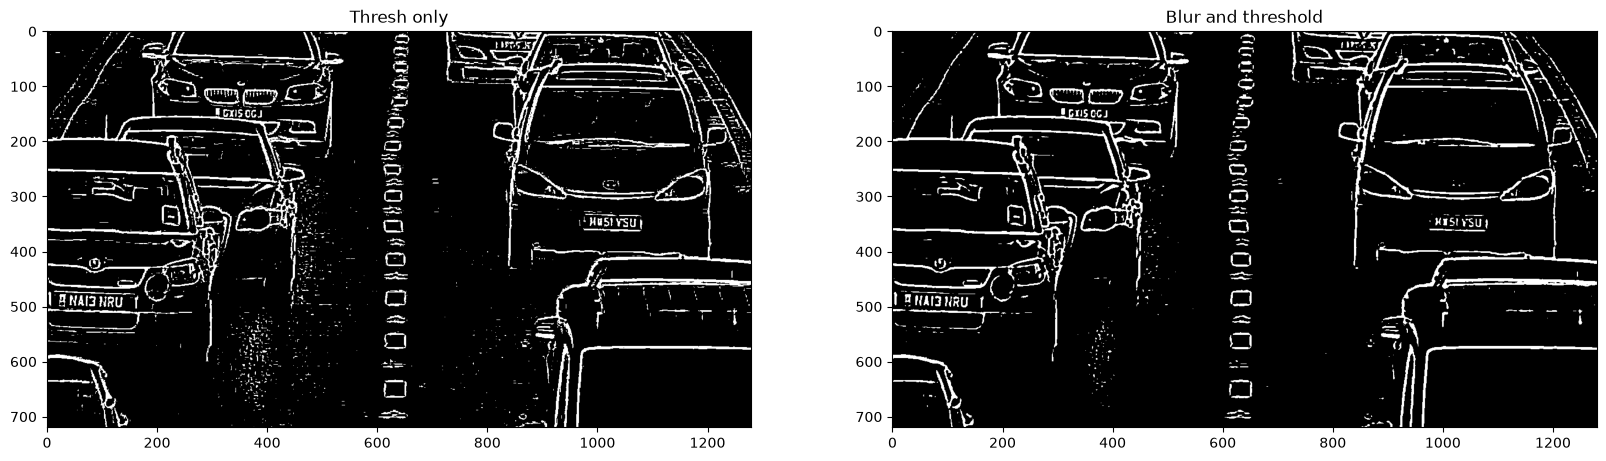

In [38]:
# threshold only
img_thresh = cv2.adaptiveThreshold(
    gray,
    maxValue=255.0,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # thresholding value를 결정하는 계산 방법
    thresholdType=cv2.THRESH_BINARY_INV,
    blockSize=19,
    C=9,
)

# blur and threshold
img_blurred = cv2.GaussianBlur(
    gray,
    ksize=(5, 5),  # kernel size
    sigmaX=0,  # X방향 sigma
)

img_blur_thresh = cv2.adaptiveThreshold(
    img_blurred,
    maxValue=255.0,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY_INV,
    blockSize=19,
    C=9,
)

# ------------------

fig, axs = plt.subplots(1, 2, figsize=(20, 20))
axs[0].set_title('Thresh only')
axs[0].imshow(img_thresh, cmap='gray')

axs[1].set_title('Blur and threshold')
axs[1].imshow(img_blur_thresh, cmap='gray')

plt.show()

# 윤곽선 그려보기

(720, 1280, 3)
714


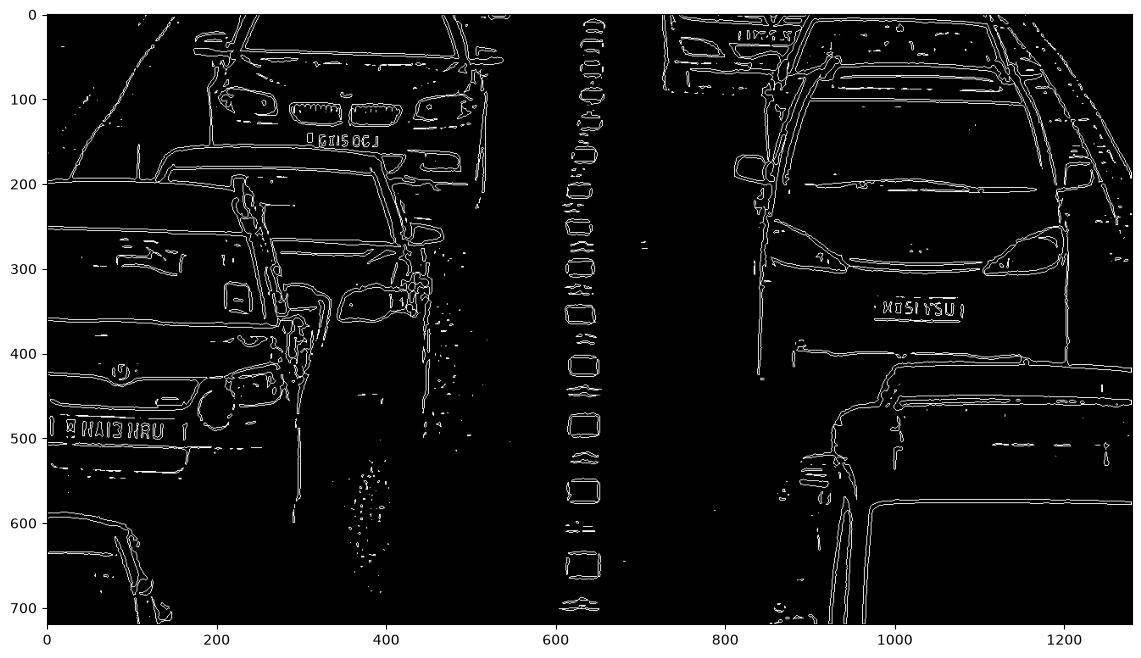

In [39]:
height, width, channel = frame.shape
print(frame.shape)   # height, width, channel

contours, _ = cv2.findContours(
    img_blur_thresh,
    mode=cv2.RETR_LIST,
    method=cv2.CHAIN_APPROX_SIMPLE,
)

print(len(contours))  # 검출된 객체의 개수

# 검정색 배경 만들고 그 위에 윤곽선 그려보기
temp_result = np.zeros((height, width, channel), dtype=np.uint8)

cv2.drawContours(
    temp_result,
    contours=contours,
    contourIdx=-1,  # contourIdx 값에 -1을 주면 전체 contour를 다 그리겠다는 뜻
    color=(255, 255, 255)
)

plt_imshow(temp_result)

# Data 수정

714


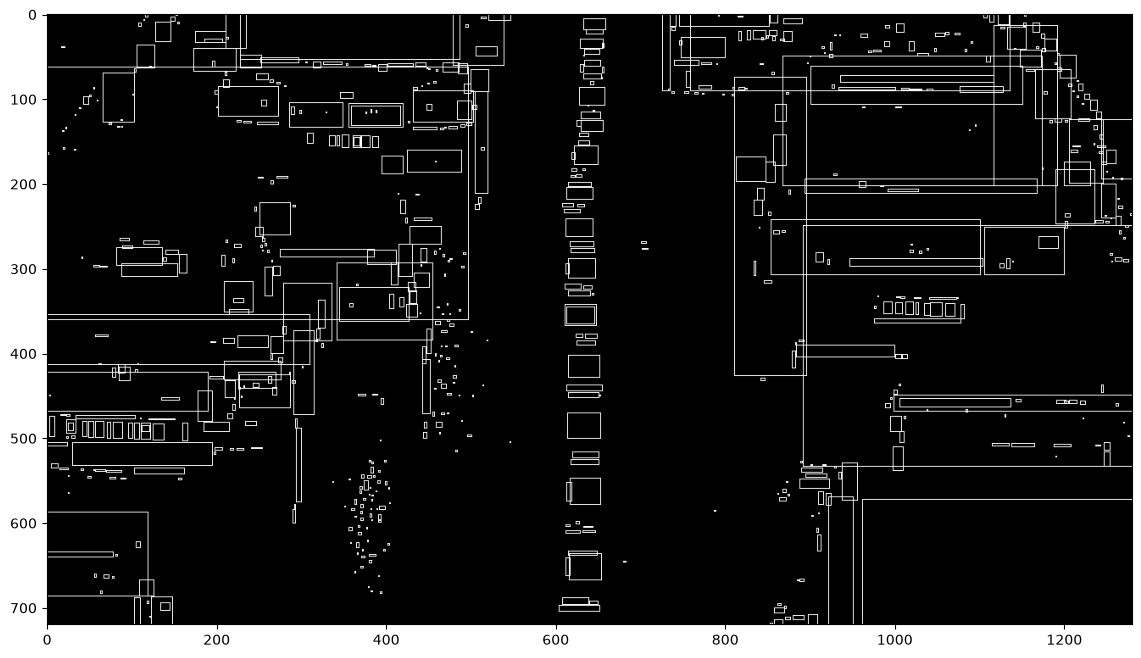

In [40]:
# 검정색 배경에 bounding rect만 그려보기
temp_result = np.zeros((height, width, channel), dtype=np.uint8)

contours_dict = []   # <- 여기다가 contours 들의 정보를 다 저장하겠습니다.

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    cv2.rectangle(temp_result, pt1=(x, y), pt2=(x + w, y + h), color=(255, 255, 255))

    contours_dict.append({
        'contour': contour,
        'x': x,
        'y': y,
        'w': w,
        'h': h,
        'cx': x + (w / 2),  # bounding rect의 중심좌표
        'cy': y + (h / 2)
    })

print(len(contours_dict))
plt_imshow(temp_result)

# Select Candidates by Char Size

In [41]:
MIN_AREA = 40  # 최소 넓이
MIN_WIDTH, MIN_HEIGHT = 2, 7  # 최소 너비, 높이
MIN_RATIO, MAX_RATIO = 0.2, 1.0  # 너비-높이 비율의 최대/최소

possible_contours = []  # 위 조건에 맞는 것들만 걸러낸 것들을 담아보겠습니다

cnt = 0
for d in contours_dict:  # 위에서 저장했었던 contours_dict 를 순환하면서
    area = d['w'] * d['h']  # 넓이 계산
    ratio = d['w'] / d['h']  # 너비/높이 비율 계산

    # 조건에 맞는 countour 들만 골라서 possible_contours 에 담는다.
    if area > MIN_AREA \
        and d['w'] > MIN_WIDTH and d['h'] > MIN_HEIGHT \
        and MIN_RATIO < ratio < MAX_RATIO:
        d['idx'] = cnt  # 조건에 맞는 각 contour에 idx값을 매겨놓고,
                        # 나중에 조건에 맞는 윤곽선들의 idx만 따로 빼낼겁니다

        cnt += 1
        possible_contours.append(d)

print(len(possible_contours))  # 몇개가 선발되었는지?
possible_contours[0]  # 첫번째만 확인

111


{'contour': array([[[899, 708]],
 
        [[898, 709]],
 
        [[899, 710]],
 
        [[900, 710]],
 
        [[901, 711]],
 
        [[902, 710]],
 
        [[903, 711]],
 
        [[903, 712]],
 
        [[904, 713]],
 
        [[904, 714]],
 
        [[905, 715]],
 
        [[905, 719]],
 
        [[908, 719]],
 
        [[908, 714]],
 
        [[902, 708]]], dtype=int32),
 'x': 898,
 'y': 708,
 'w': 11,
 'h': 12,
 'cx': 903.5,
 'cy': 714.0,
 'idx': 0}

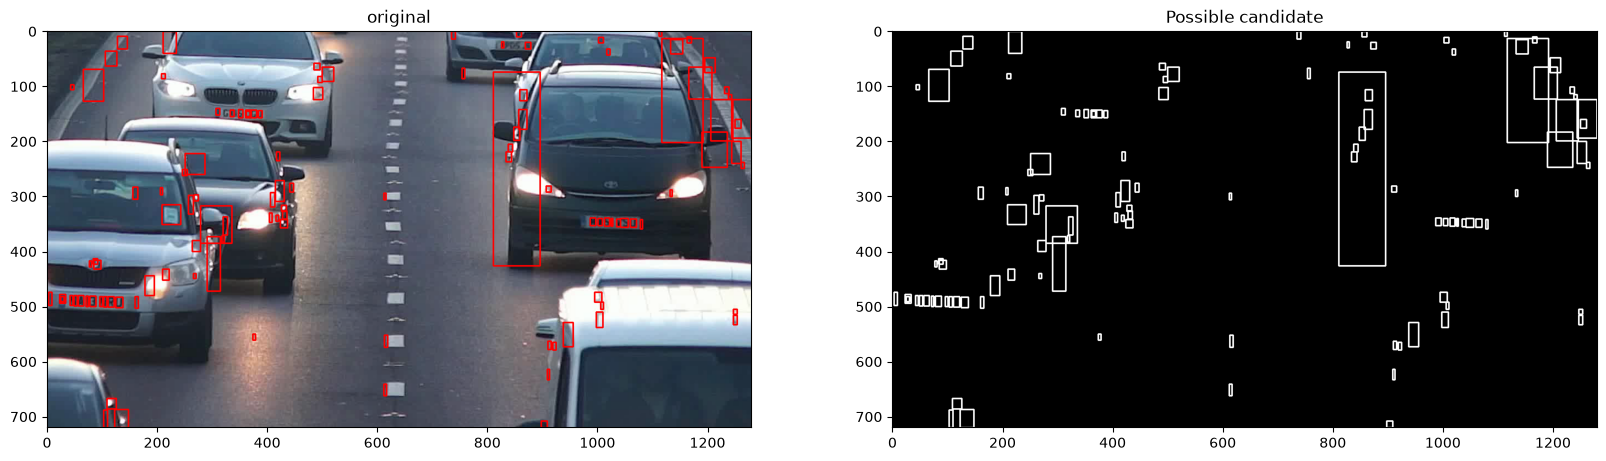

In [42]:
# 뽑힌 contour 들 (번호판 숫자 조건에 합한 후보들)을 시각화 해보자
# 원본이미지 위에도 그려보고,  검정색 이미지 위에도 그려보아 비교해보자

temp_result = np.zeros((height, width, channel), dtype=np.uint8)
temp_original = frame.copy()

for d in possible_contours:
    cv2.rectangle(temp_result, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(255, 255, 255), thickness=2)
    cv2.rectangle(temp_original, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(0, 0, 255), thickness=2)

fig, axs = plt.subplots(1, 2, figsize=(20, 20))

axs[0].set_title('original')
axs[0].imshow(cv2.cvtColor(temp_original, cv2.COLOR_BGR2RGB))

axs[1].set_title('Possible candidate')
axs[1].imshow(temp_result, cmap='gray')

plt.show()

# 배치에 따른 번호판 후보 추출

In [49]:
# contour 와 contour 사이의 길이 제한
MAX_DIAG_MULTIPLYER = 4.0

MAX_ANGLE_DIFF = 10.0
# 면적의 차이
MAX_AREA_DIFF = 0.4
# 너비, 높이의 차이
MAX_WIDTH_DIFF = 0.6
MAX_HEIGHT_DIFF = 0.25

MIN_N_MATCHED = 4

In [50]:
# 번호판 글자 그룹을 찾는 함수 정의
# possible_contours를 매개변수로 넘겨줄거다
def find_chars(contour_list):
    matched_result_idx = []   # 최종적으로 남는 index 값을 담아서 리턴할거다

    # contour_list에서 가용한 모든 contour (d1, d2) 두개의 조합을 비교
    for d1 in contour_list:
        matched_contours_idx = []   # 'd1'과 '조건 통과된 contour(d2들)'을 담을거다

        for d2 in contour_list:
            if d1['idx'] == d2['idx']:   # d1과 d2가 같으면 넘어가구.
                continue

            # 두 contour 사이의 거리를 구하기 위해 dx, dy 계산
            dx = abs(d1['cx'] - d2['cx'])
            dy = abs(d1['cy'] - d2['cy'])
            distance = np.linalg.norm(np.array([d1['cx'], d1['cy']]) - np.array([d2['cx'], d2['cy']]))

            # d1의 대각선 길이
            diagonal_length1 = np.sqrt(d1['w'] ** 2 + d1['h'] ** 2)

            # 각도 구하기
            if dx == 0:  # dx가 0이면 90도
                angle_diff = 90
            else:
                angle_diff = np.degrees(np.arctan(dy / dx))  # arctan()의 리턴값은 radian 값이다
                                                             # 이를 호도법으로 변환 np.degrees()

            # 면적 비율, 폭 비율, 높이 비율
            area_diff = abs(d1['w'] * d1['h'] - d2['w'] * d2['h']) / (d1['w'] * d1['h'])
            width_diff = abs(d1['w'] - d2['w']) / d1['w']
            height_diff = abs(d1['h'] - d2['h']) / d1['h']

            # 조건에 맞는 contour만 골라서 matched_contours_idx에 index 추가
            # 즉 d1과 같은 번호판 후보군 d2(들)을 추가
            if distance < diagonal_length1 * MAX_DIAG_MULTIPLYER \
            and angle_diff < MAX_ANGLE_DIFF and area_diff < MAX_AREA_DIFF \
            and width_diff < MAX_WIDTH_DIFF and height_diff < MAX_HEIGHT_DIFF:
                matched_contours_idx.append(d2['idx'])

        # 마지막에는 d1도 넣어준다
        matched_contours_idx.append(d1['idx'])

        # 그룹에 MIN_N_MATCHED보다 적은 개수가 담겨 있으면 번호판 탈락!
        if len(matched_contours_idx) < MIN_N_MATCHED:
            continue

        # 조건을 다 통과하면 최종 후보군 matched_result_idx에 인덱스 추가
        matched_result_idx.append(matched_contours_idx)

        # 최종후보군에 들어있지 않은 것들을 한번 더 비교해볼거다
        unmatched_contour_idx = []
        for d4 in contour_list:
            if d4['idx'] not in matched_contours_idx:
                unmatched_contour_idx.append(d4['idx'])

        unmatched_contour = np.take(possible_contours, unmatched_contour_idx)

        # 재귀호출
        recursive_contour_list = find_chars(unmatched_contour)

        for idx in recursive_contour_list:
            matched_result_idx.append(idx)

        break

    return matched_result_idx

In [51]:
# 결과 확인
result_idx = find_chars(possible_contours)
result_idx

[[18, 21, 23, 15],
 [17, 20, 22, 24, 25, 19],
 [42, 44, 45, 46, 40],
 [74, 78, 79, 80, 75]]

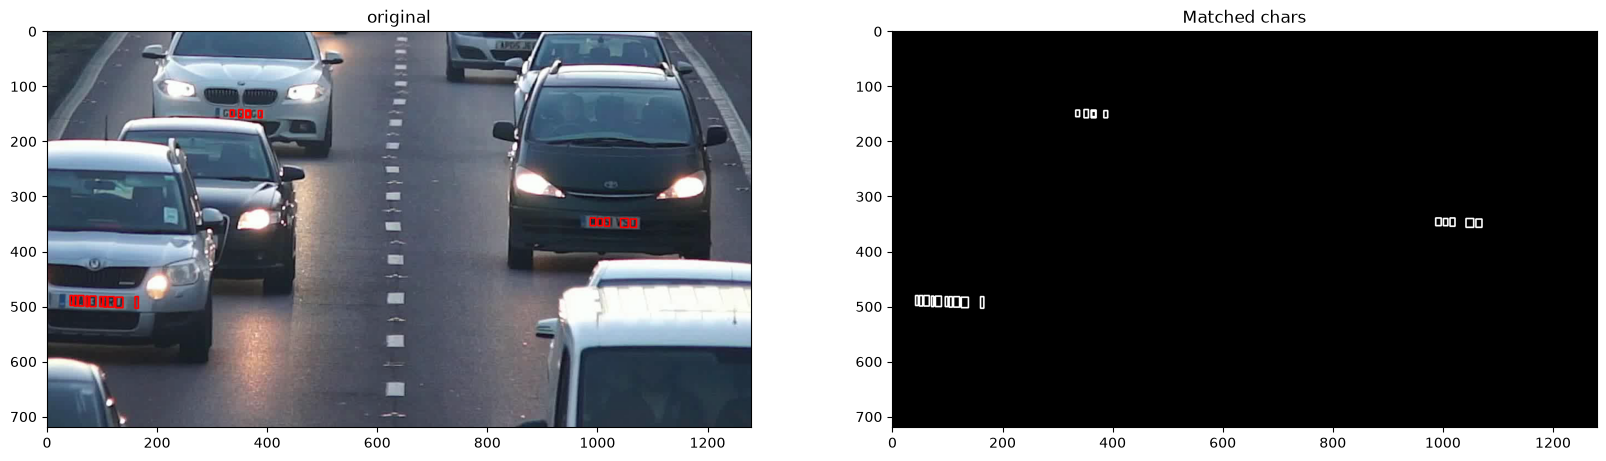

In [52]:
matched_result = []
for idx_list in result_idx:
    matched_result.append(np.take(possible_contours, idx_list))

temp_result = np.zeros((height, width, channel), dtype=np.uint8)
temp_original = frame.copy()

for r in matched_result:
    for d in r:
        cv2.rectangle(temp_result, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(255, 255, 255), thickness=2)
        cv2.rectangle(temp_original, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(0, 0, 255), thickness=2)

fig, axs = plt.subplots(1, 2, figsize=(20, 20))
axs[0].set_title('original')
axs[0].imshow(cv2.cvtColor(temp_original, cv2.COLOR_BGR2RGB))
axs[1].set_title('Matched chars')
axs[1].imshow(temp_result, cmap='gray')
plt.show()

# Transform Plate Images

In [55]:
PLATE_WIDTH_PADDING = 2.0
PLATE_HEIGHT_PADDING = 1.7

MIN_PLATE_RATIO = 2.5   # 번호판 전체 가로 세로 비율 최소(min)
MAX_PLATE_RATIO = 9.0   # 번호판 전체 가로 세로 비율 최대(max)

plate_imgs = []
plate_infos = []

for i, matched_chars in enumerate(matched_result):
    # 일단 center X 기준으로 정렬 해준다. (직전까지의 순서는 뒤죽박죽)
    sorted_chars = sorted(matched_chars, key=lambda x: x['cx'])

    # 번호판의 center 좌표를 계산해본다. (첫 contour ~ 마지막 contour의 center 거리)
    plate_cx = (sorted_chars[0]['cx'] + sorted_chars[-1]['cx']) / 2
    plate_cy = (sorted_chars[0]['cy'] + sorted_chars[-1]['cy']) / 2

    # 번호판의 width 계산
    plate_width = (sorted_chars[-1]['x'] - sorted_chars[0]['x'] + sorted_chars[-1]['w']) * PLATE_WIDTH_PADDING

    # 번호판의 height 계산
    sum_height = 0
    for d in sorted_chars:
        sum_height += d['h']

    plate_height = int((sum_height / len(sorted_chars)) * PLATE_HEIGHT_PADDING)

    if plate_height == 0:
        continue

    # 회전 각도 구하기
    triangle_height = sorted_chars[-1]['cy'] - sorted_chars[0]['cy']  # 높이

    triangle_hypotenus = np.linalg.norm(  # 빗변(hypotenus) 구하기
        np.array([sorted_chars[0]['cx'], sorted_chars[0]['cy']]) -
        np.array([sorted_chars[-1]['cx'], sorted_chars[-1]['cy']])
    )

    # 높이와 빗변을 사용해서 arcsin() 함수로 각도 계산
    if triangle_hypotenus == 0:
        angle = 0.0
    else:
        angle = np.degrees(np.arcsin(triangle_height / triangle_hypotenus))

    print('회전각도', angle)

    # 위 각도가 나오면 회전하는 transformation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center=(plate_cx, plate_cy), angle=angle, scale=1.0)

    # 이를 이미지에 적용하기  (수업은 img_blur_thresh, 여기서는 gray 를 쓴다)
    img_rotated = cv2.warpAffine(gray, M=rotation_matrix, dsize=(width, height))

    # 번호판 부분만 잘라낸다
    img_cropped = cv2.getRectSubPix(
        img_rotated,
        patchSize=(int(plate_width), int(plate_height)),
        center=(int(plate_cx), int(plate_cy)),
    )

    # 위 결과가 번호판의 가로세로 비율조건에 맞지 않으면 스킵한다
    if img_cropped.shape[1] / img_cropped.shape[0] < MIN_PLATE_RATIO \
    or img_cropped.shape[1] / img_cropped.shape[0] > MAX_PLATE_RATIO:
        continue

    plate_imgs.append(img_cropped)
    plate_infos.append({
        'x': int(plate_cx - plate_width / 2),
        'y': int(plate_cy - plate_height / 2),
        'w': int(plate_width),
        'h': int(plate_height)
    })

print('잘라낸 번호판 :', len(plate_imgs), '개')

회전각도 2.471664761633412
회전각도 1.691788568264482
회전각도 1.9480850065149489
회전각도 1.6846843178962916


4
0 {'x': 15, 'y': 475, 'w': 162, 'h': 32} (32, 162)


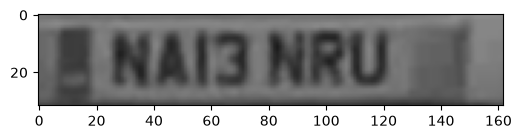

1 {'x': -20, 'y': 474, 'w': 248, 'h': 32} (32, 248)


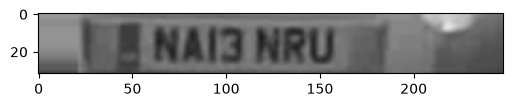

2 {'x': 944, 'y': 335, 'w': 168, 'h': 24} (24, 168)


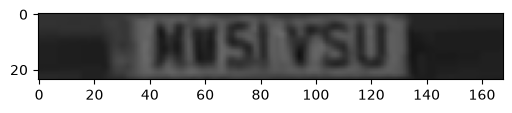

3 {'x': 304, 'y': 139, 'w': 116, 'h': 21} (21, 116)


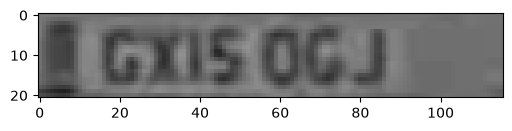

In [60]:
print(len(plate_imgs))  # 발견한 번호판들의 
for i, plate_img in enumerate(plate_imgs):
    print(i, plate_infos[i], plate_img.shape)
    plt_imshow(plate_img, figsize=(6, 2))

# 겹치는 번호판 박스 정리

겹침 제거 전 : 4 개
겹침 제거 후 : 3 개
0 {'x': -20, 'y': 474, 'w': 248, 'h': 32} (32, 248)


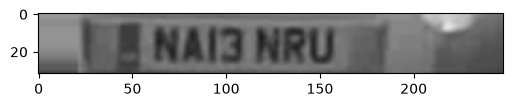

1 {'x': 944, 'y': 335, 'w': 168, 'h': 24} (24, 168)


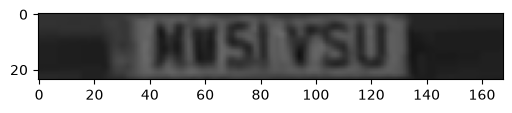

2 {'x': 304, 'y': 139, 'w': 116, 'h': 21} (21, 116)


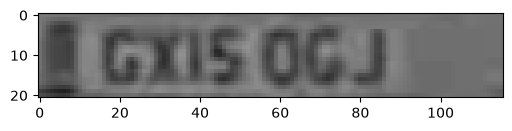

In [61]:
def remove_overlap(plate_imgs, plate_infos, thresh=0.3):
    """겹치는 번호판 박스는 넓은 것 하나만 남긴다"""

    # 넓이가 큰 것부터 보기 위해 순서를 정한다
    order = sorted(range(len(plate_infos)),
                   key=lambda i: -(plate_infos[i]['w'] * plate_infos[i]['h']))

    keep_imgs = []
    keep_infos = []

    for i in order:
        x = plate_infos[i]['x']
        y = plate_infos[i]['y']
        w = plate_infos[i]['w']
        h = plate_infos[i]['h']

        overlapped = False
        for k in keep_infos:            # 이미 남기기로 한 것들과 비교
            X, Y, W, H = k['x'], k['y'], k['w'], k['h']

            # 겹치는 사각형의 가로/세로 길이
            iw = max(0, min(x + w, X + W) - max(x, X))
            ih = max(0, min(y + h, Y + H) - max(y, Y))

            # 겹친 넓이가 '작은 쪽 넓이'의 30% 를 넘으면 같은 번호판으로 본다
            if iw * ih / min(w * h, W * H) > thresh:
                overlapped = True
                break

        if not overlapped:
            keep_imgs.append(plate_imgs[i])
            keep_infos.append(plate_infos[i])

    return keep_imgs, keep_infos


print('겹침 제거 전 :', len(plate_imgs), '개')
plate_imgs, plate_infos = remove_overlap(plate_imgs, plate_infos)
print('겹침 제거 후 :', len(plate_imgs), '개')

for i, plate_img in enumerate(plate_imgs):
    print(i, plate_infos[i], plate_img.shape)
    plt_imshow(plate_img, figsize=(6, 2))

# 번호판 이미지 다듬기

In [62]:
TARGET_H = 64          # 번호판 crop 을 이 높이로 확대한다
MIN_PLATE_CHARS = 4    # 글자가 이보다 적게 잡히면 번호판이 아니라고 본다


def refine_plate(crop):
    """번호판 crop 에서 글자 범위만 다시 찾아 잘라내고, 여백을 붙여 리턴"""
    if crop is None or crop.shape[0] < 5:
        return None

    # 1) 크기를 일정하게 맞춘다 (높이 64)
    scale = TARGET_H / crop.shape[0]
    img = cv2.resize(crop, dsize=(0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # 2) threshold 이진화 (OTSU) -> 흰 바탕에 검은 글자
    _, binary = cv2.threshold(img, thresh=0.0, maxval=255.0, 
                              cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 3) 글자 윤곽선 찾기 (findContours 는 흰색을 찾으므로 반전해서 넣는다)
    contours, _ = cv2.findContours(cv2.bitwise_not(binary),
                                   mode=cv2.RETR_LIST,
                                   method=cv2.CHAIN_APPROX_SIMPLE)

    ch, cw = binary.shape
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if h < ch * 0.25 or h > ch * 0.90:   # 너무 작은 잡티 / 너무 큰 테두리 제외
            continue
        if w < 2 or w > h * 1.2:             # 가로로 퍼진 테두리 선 제외
            continue
        boxes.append((x, y, w, h))

    if len(boxes) < MIN_PLATE_CHARS:
        return None

    # 4) 같은 줄에 나란히 있는 것만 남긴다 (EU 파란띠, 나사 자국 제거)
    med_h = np.median([b[3] for b in boxes])              # 높이의 중앙값
    med_cy = np.median([b[1] + b[3] / 2 for b in boxes])  # 세로 중심의 중앙값

    keep = []
    for b in boxes:
        cy = b[1] + b[3] / 2
        if abs(b[3] - med_h) < med_h * 0.32 and abs(cy - med_cy) < med_h * 0.30:
            keep.append(b)

    if len(keep) < MIN_PLATE_CHARS:
        return None

    # 5) 남은 글자들을 다 담는 범위로 자른다
    plate_min_x = min(b[0] for b in keep)
    plate_max_x = max(b[0] + b[2] for b in keep)
    plate_min_y = min(b[1] for b in keep)
    plate_max_y = max(b[1] + b[3] for b in keep)

    img_result = binary[max(plate_min_y - 3, 0):plate_max_y + 3,
                        max(plate_min_x - 3, 0):plate_max_x + 3]
    if img_result.size == 0:
        return None

    # 6) 노이즈 제거 (blur + threshold)
    img_result = cv2.GaussianBlur(img_result, ksize=(3, 3), sigmaX=0)
    
    _, img_result = cv2.threshold(img_result, thresh=0.0, maxval=255.0,
                                  cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 7) tesseract 가 잘 읽도록 여백을 준다 (글자가 검정이므로 흰색 여백)
    img_result = cv2.copyMakeBorder(img_result,
                                    top=18, bottom=18, left=18, right=18,
                                    borderType=cv2.BORDER_CONSTANT, value=255)
    return img_result

--- 0 {'x': -20, 'y': 474, 'w': 248, 'h': 32}


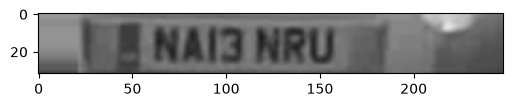

    글자를 못 찾음 -> 버림
--- 1 {'x': 944, 'y': 335, 'w': 168, 'h': 24}


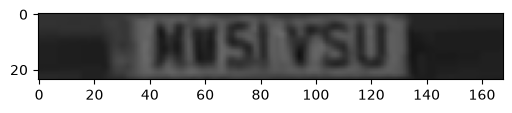

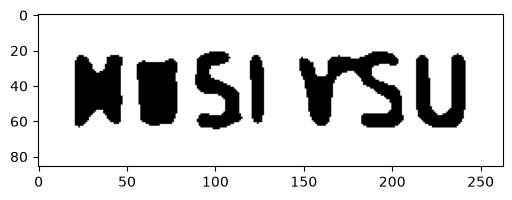

--- 2 {'x': 304, 'y': 139, 'w': 116, 'h': 21}


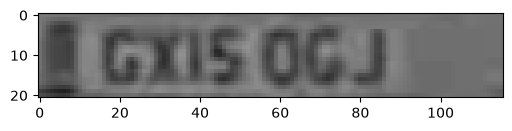

    글자를 못 찾음 -> 버림
다듬기 성공 : 1 개


In [63]:
plate_results = []      # 다듬은 이미지
plate_results_info = [] # 그 이미지의 원본 좌표

for i, plate_img in enumerate(plate_imgs):
    img_result = refine_plate(plate_img)

    print('---', i, plate_infos[i])
    plt_imshow(plate_img, figsize=(6, 2))          # 다듬기 전

    if img_result is None:
        print('    글자를 못 찾음 -> 버림')
        continue

    plt_imshow(img_result, figsize=(6, 2))         # 다듬은 후
    plate_results.append(img_result)
    plate_results_info.append(plate_infos[i])

print('다듬기 성공 :', len(plate_results), '개')

# OCR 문자 인식

In [66]:
OCR_CFG = ('--psm 7 --oem 1 '
           '-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')


def read_plate_raw(img_result):
    """다듬은 번호판 이미지 -> 글자와 숫자만 남긴 문자열"""
    chars = pytesseract.image_to_string(
        img_result,
        lang='eng',
        config=OCR_CFG
    )

    # 읽어낸 문자열에 줄바꿈이나 이상한 기호가 섞여 나온다. 글자/숫자만 남긴다
    result_chars = re.sub(r'[^A-Z0-9]', '', chars.upper())

    return result_chars

[0] {'x': 944, 'y': 335, 'w': 168, 'h': 24}  ->  "MESIVSU"  (7글자)


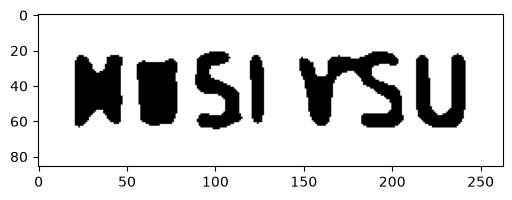

In [67]:
for i, img_result in enumerate(plate_results):
    chars = read_plate_raw(img_result)
    print(f'[{i}] {plate_results_info[i]}  ->  "{chars}"  ({len(chars)}글자)')
    plt_imshow(img_result, figsize=(6, 2))

# 번호판 형식으로 교정
번호판: 영어2 + 숫자2 + 영어3

In [68]:
# 영국 번호판 형식 : 글자2 + 숫자2 + 글자3
PLATE_RE = re.compile(r'[A-Z]{2}\d{2}[A-Z]{3}')

# 숫자 자리인데 글자로 읽힌 경우 -> 숫자로
TO_DIGIT = {'O': '0', 'Q': '0', 'D': '0',
            'I': '1', 'L': '1', 'J': '1',
            'Z': '2', 'S': '5', 'B': '8',
            'G': '6', 'T': '7', 'A': '4'}

# 글자 자리인데 숫자로 읽힌 경우 -> 글자로
TO_ALPHA = {'0': 'O', '1': 'I', '2': 'Z', '5': 'S',
            '8': 'B', '6': 'G', '4': 'A', '7': 'T'}


def correct_format(text):
    """영국 번호판 형식에 맞춰 헷갈리는 글자를 고친다
    리턴 : (고친 문자열, 형식에 맞는지 여부)"""

    if len(text) != 7:          # 7글자가 아니면 번호판이 아니다
        return text, False

    fixed = ''
    for i, c in enumerate(text):
        if i in (2, 3):                     # 3, 4번째 자리는 숫자여야 한다
            fixed += TO_DIGIT.get(c, c)
        else:                               # 나머지는 글자여야 한다
            fixed += TO_ALPHA.get(c, c)

    ok = bool(PLATE_RE.fullmatch(fixed))
    return fixed, ok

In [69]:
plate_chars = []       # 최종 인식된 번호판 문자열
plate_chars_info = []  # 그 번호판의 원본 좌표

for i, img_result in enumerate(plate_results):
    raw = read_plate_raw(img_result)
    fixed, ok = correct_format(raw)

    print(f'[{i}] "{raw}" -> "{fixed}"   형식통과 = {ok}')

    if ok:
        plate_chars.append(fixed)
        plate_chars_info.append(plate_results_info[i])

print()
print('인식한 번호판 :', plate_chars)

[0] "MESIVSU" -> "ME51VSU"   형식통과 = True

인식한 번호판 : ['ME51VSU']


# 함수로 묶기

In [70]:
def detect_plates(frame):
    """프레임 한 장 -> (번호판 crop 리스트, 좌표 리스트)"""
    global possible_contours     # find_chars 안에서 이 변수를 참조하기 때문에 global

    height, width, channel = frame.shape

    # --- 2단계 : 흑백 -> 블러 -> 이진화 ---
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    img_blurred = cv2.GaussianBlur(gray, ksize=(5, 5), sigmaX=0)
    img_blur_thresh = cv2.adaptiveThreshold(img_blurred, 255.0,
                                            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                            cv2.THRESH_BINARY_INV, 19, 9)

    # --- 3단계 : 윤곽선 -> 글자 후보 ---
    contours, _ = cv2.findContours(img_blur_thresh,
                                   mode=cv2.RETR_LIST,
                                   method=cv2.CHAIN_APPROX_SIMPLE)

    possible_contours = []
    cnt = 0
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if h == 0:
            continue
        area = w * h
        ratio = w / h
        if area > MIN_AREA and w > MIN_WIDTH and h > MIN_HEIGHT \
        and MIN_RATIO < ratio < MAX_RATIO:
            possible_contours.append({'x': x, 'y': y, 'w': w, 'h': h,
                                      'cx': x + (w / 2), 'cy': y + (h / 2),
                                      'idx': cnt})
            cnt += 1

    if len(possible_contours) < MIN_N_MATCHED:
        return [], []

    # --- 4단계 : 배치로 그룹 만들기 ---
    result_idx = find_chars(possible_contours)

    # --- 5단계 : 회전 보정 후 잘라내기 ---
    plate_imgs = []
    plate_infos = []

    for idx_list in result_idx:
        matched_chars = np.take(possible_contours, idx_list)
        sorted_chars = sorted(matched_chars, key=lambda x: x['cx'])

        plate_cx = (sorted_chars[0]['cx'] + sorted_chars[-1]['cx']) / 2
        plate_cy = (sorted_chars[0]['cy'] + sorted_chars[-1]['cy']) / 2
        plate_width = (sorted_chars[-1]['x'] - sorted_chars[0]['x'] + sorted_chars[-1]['w']) * PLATE_WIDTH_PADDING

        sum_height = 0
        for d in sorted_chars:
            sum_height += d['h']
        plate_height = int((sum_height / len(sorted_chars)) * PLATE_HEIGHT_PADDING)
        if plate_height == 0:
            continue

        triangle_height = sorted_chars[-1]['cy'] - sorted_chars[0]['cy']
        triangle_hypotenus = np.linalg.norm(
            np.array([sorted_chars[0]['cx'], sorted_chars[0]['cy']]) -
            np.array([sorted_chars[-1]['cx'], sorted_chars[-1]['cy']]))
        if triangle_hypotenus == 0:
            angle = 0.0
        else:
            angle = np.degrees(np.arcsin(triangle_height / triangle_hypotenus))

        rotation_matrix = cv2.getRotationMatrix2D(center=(plate_cx, plate_cy), angle=angle, scale=1.0)
        img_rotated = cv2.warpAffine(gray, M=rotation_matrix, dsize=(width, height))
        img_cropped = cv2.getRectSubPix(img_rotated,
                                        patchSize=(int(plate_width), int(plate_height)),
                                        center=(int(plate_cx), int(plate_cy)))

        if img_cropped.shape[1] / img_cropped.shape[0] < MIN_PLATE_RATIO \
        or img_cropped.shape[1] / img_cropped.shape[0] > MAX_PLATE_RATIO:
            continue

        plate_imgs.append(img_cropped)
        plate_infos.append({'x': int(plate_cx - plate_width / 2),
                            'y': int(plate_cy - plate_height / 2),
                            'w': int(plate_width),
                            'h': int(plate_height)})

    # --- 6단계 : 겹치는 박스 정리 ---
    return remove_overlap(plate_imgs, plate_infos)

In [71]:
def read_plate(plate_img):
    """번호판 crop 한 장 -> (번호판 문자열, 형식 통과 여부)"""
    img_result = refine_plate(plate_img)        # 7단계
    if img_result is None:
        return None, False
    raw = read_plate_raw(img_result)            # 8단계
    return correct_format(raw)                  # 9단계

In [72]:
GT = {0:   ['NA13NRU', 'MW51VSU', 'GX15OGJ'],
      90:  ['GX15OGJ'],
      270: ['WR02FKD', 'EY61NBG'],
      448: ['BG65USJ', 'NA54KGJ', 'NK64DMV']}

cap = cv2.VideoCapture(video_path)
test_frames = {}
cnt = 0
while True:
    ret, img = cap.read()
    if not ret:
        break
    if cnt in GT:
        test_frames[cnt] = img
    cnt += 1
cap.release()

print('테스트 프레임', len(test_frames), '장 준비')

테스트 프레임 4 장 준비


In [73]:
hit = 0
tot = 0
t0 = time.time()

for no, answers in GT.items():
    plate_imgs, plate_infos = detect_plates(test_frames[no])

    got = set()
    for plate_img in plate_imgs:
        text, ok = read_plate(plate_img)
        if ok:
            got.add(text)

    tot += len(answers)
    hit += len(got & set(answers))

    print(f'frame {no:4d}  검출 {len(plate_imgs)}개')
    print(f'            인식 {sorted(got)}')
    print(f'            정답 {sorted(answers)}')

elapsed = time.time() - t0
print(f'\n정답률 {hit}/{tot}   ({elapsed:.2f}초, 프레임당 {elapsed/len(GT):.2f}초)')

frame    0  검출 3개
            인식 ['ME51VSU']
            정답 ['GX15OGJ', 'MW51VSU', 'NA13NRU']
frame   90  검출 1개
            인식 ['GX15OGJ']
            정답 ['GX15OGJ']
frame  270  검출 2개
            인식 ['EY61NBG', 'WR02FKD']
            정답 ['EY61NBG', 'WR02FKD']
frame  448  검출 3개
            인식 ['BG65USJ', 'NA54KGJ', 'VK64DMV']
            정답 ['BG65USJ', 'NA54KGJ', 'NK64DMV']

정답률 5/9   (0.68초, 프레임당 0.17초)


--- frame 0


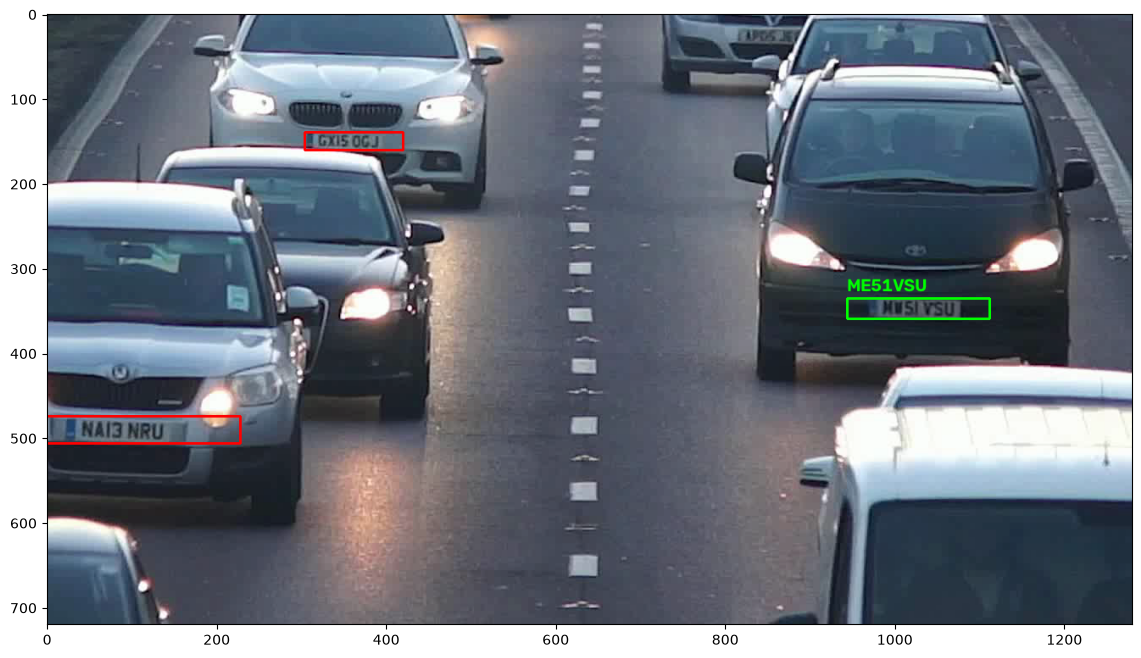

--- frame 90


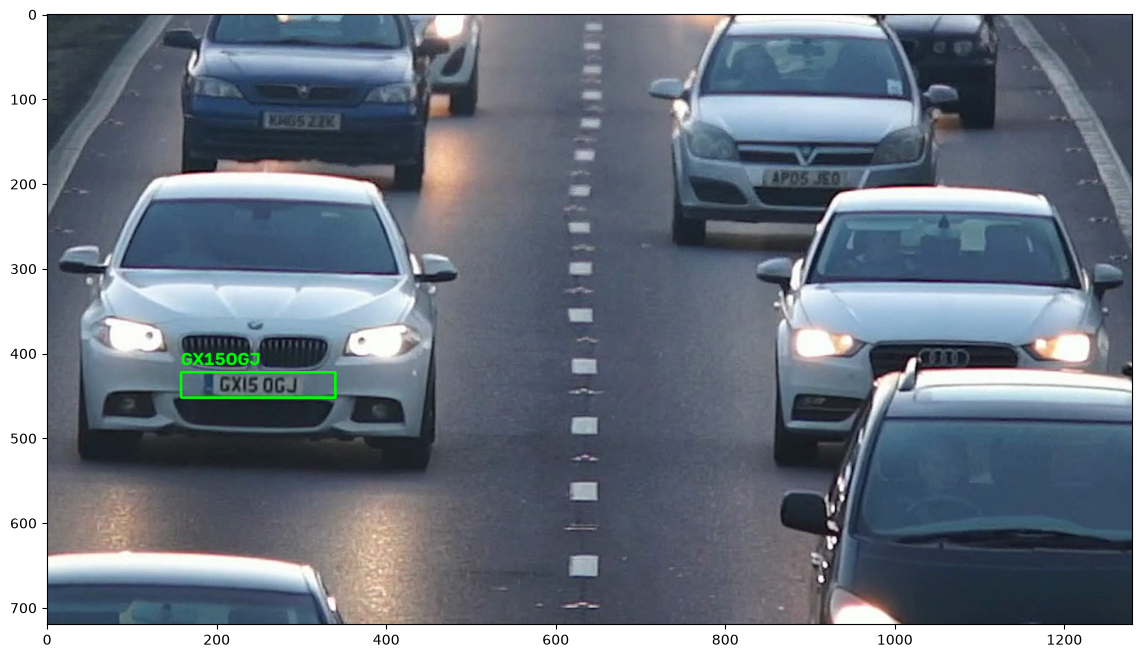

--- frame 270


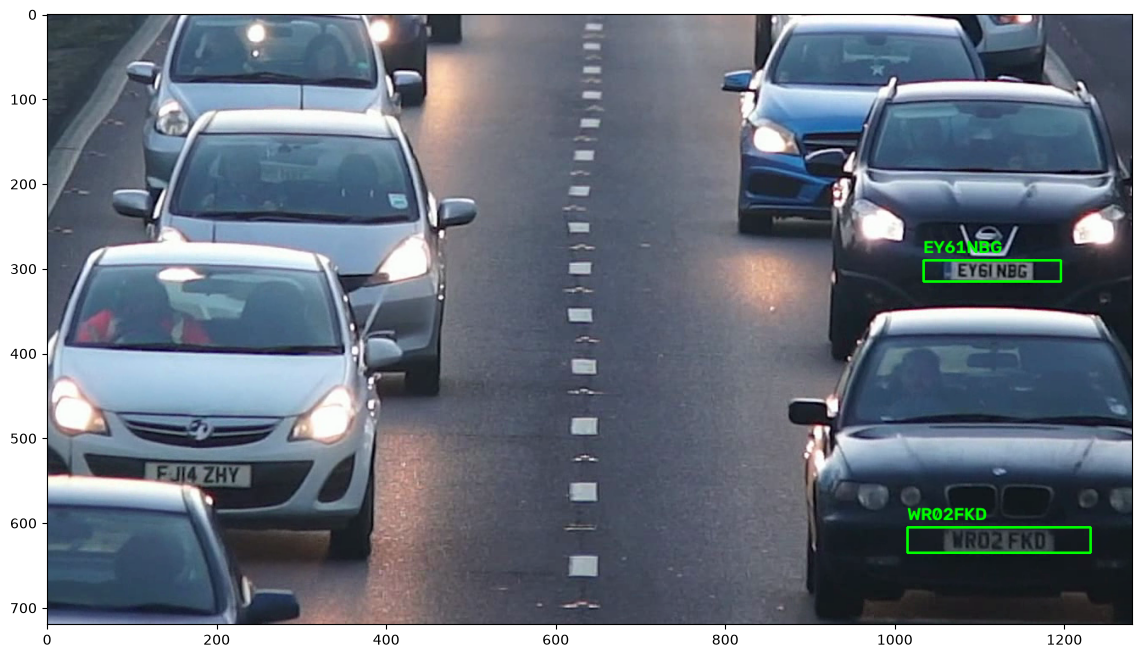

--- frame 448


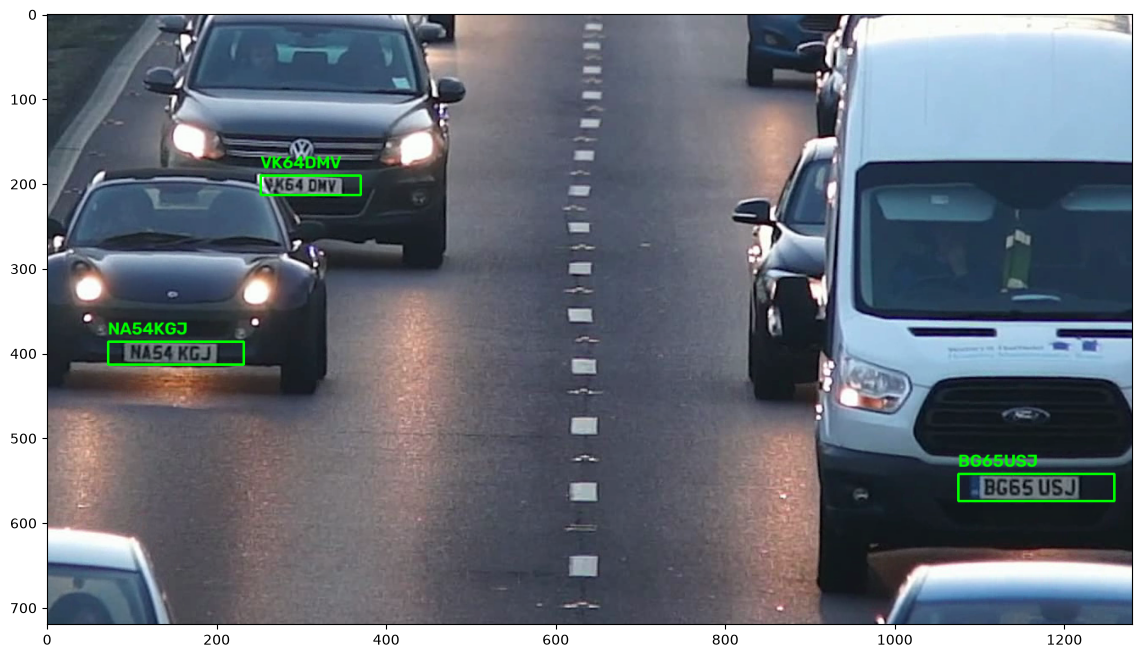

In [74]:
for no in GT:
    frame_vis = test_frames[no].copy()
    plate_imgs, plate_infos = detect_plates(frame_vis)

    for plate_img, info in zip(plate_imgs, plate_infos):
        text, ok = read_plate(plate_img)
        color = (0, 255, 0) if ok else (0, 0, 255)     # 통과 초록 / 실패 빨강

        cv2.rectangle(frame_vis,
                      pt1=(info['x'], info['y']),
                      pt2=(info['x'] + info['w'], info['y'] + info['h']),
                      color=color, thickness=2)

        if text:
            cv2.putText(frame_vis, text, (info['x'], info['y'] - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    print('--- frame', no)
    plt_imshow(frame_vis)

# 프레임 사이에서 같은 번호판 이어붙이기 (추적)

In [75]:
TRACK_MAX_MISS = 8       # 8프레임 동안 안 보이면 추적 종료


def match_tracks(tracks, plate_infos):
    """이번 프레임에 검출된 박스들을 기존 추적에 이어붙인다.
    이어붙은 박스의 번호 목록을 리턴한다"""
    used = []

    for tr in tracks:
        # 추적이 기억하고 있는 마지막 위치의 중심
        tcx = tr['box']['x'] + tr['box']['w'] / 2
        tcy = tr['box']['y'] + tr['box']['h'] / 2

        best = -1
        best_dist = None

        for i, info in enumerate(plate_infos):
            if i in used:                 # 이미 다른 추적이 가져간 박스는 건너뛴다
                continue

            cx = info['x'] + info['w'] / 2
            cy = info['y'] + info['h'] / 2
            dist = np.linalg.norm(np.array([cx, cy]) - np.array([tcx, tcy]))

            # 번호판 폭의 60% 안에 있어야 같은 차로 본다
            limit = max(tr['box']['w'], info['w']) * 0.6

            if dist < limit and (best_dist is None or dist < best_dist):
                best = i
                best_dist = dist

        if best >= 0:                     # 짝을 찾았다
            used.append(best)
            tr['box'] = plate_infos[best]     # 위치 갱신
            tr['miss'] = 0
            tr['cur'] = best                  # 이번 프레임의 몇 번째 박스인지
            tr['seen'] += 1
        else:                             # 이번 프레임엔 안 보였다
            tr['miss'] += 1
            tr['cur'] = -1

    return used

In [76]:
OCR_INTERVAL = 4          # 한 번호판당 4프레임에 1번만 OCR
MAX_OCR_PER_TRACK = 12    # 한 번호판당 OCR 최대 횟수
CONFIRM_VOTES = 3         # 같은 문자열이 3번 나오면 확정하고 OCR 중단
MIN_OCR_WIDTH = 55        # 번호판 폭이 이보다 작으면 OCR 하지 않는다

In [79]:
cap = cv2.VideoCapture(video_path)

tracks = []
next_id = 0
frame_cnt = 0
ocr_calls = 0
found = {}          # 확정된 번호판 {문자열: 처음 확정된 프레임}

t0 = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_cnt += 1

    # 1) 검출
    plate_imgs, plate_infos = detect_plates(frame)

    # 2) 기존 추적과 이어붙이기
    used = match_tracks(tracks, plate_infos)

    # 3) 새로 나타난 번호판 등록
    for i, info in enumerate(plate_infos):
        if i not in used:
            tracks.append({'id': next_id, 'box': info, 'miss': 0, 'cur': i,
                           'seen': 1,
                           'votes': {},
                           'text': '',
                           'confirmed': False,
                           'ocr_count': 0,
                           'last_ocr': -999})
            next_id += 1

    # 4) 오래 안 보인 추적 종료
    tracks = [tr for tr in tracks if tr['miss'] <= TRACK_MAX_MISS]

    # 5) OCR — 필요한 것만!
    for tr in tracks:
        if tr['cur'] < 0:                                  continue
        if tr['confirmed']:                                continue
        if tr['ocr_count'] >= MAX_OCR_PER_TRACK:           continue
        if tr['box']['w'] < MIN_OCR_WIDTH:                 continue
        if frame_cnt - tr['last_ocr'] < OCR_INTERVAL:      continue

        tr['last_ocr'] = frame_cnt
        tr['ocr_count'] += 1
        ocr_calls += 1

        text, ok = read_plate(plate_imgs[tr['cur']])

        if ok:
            tr['votes'][text] = tr['votes'].get(text, 0) + 1
            tr['text'] = max(tr['votes'], key=tr['votes'].get)

            if tr['votes'][tr['text']] >= CONFIRM_VOTES:
                tr['confirmed'] = True
                if tr['text'] not in found:
                    found[tr['text']] = frame_cnt
                    print(f'[frame {frame_cnt:4d}] 번호판 인식 : {tr["text"]}')

cap.release()

elapsed = time.time() - t0
print('-' * 55)
print(f'{frame_cnt}프레임 / {elapsed:.1f}초  ({frame_cnt/elapsed:.1f} fps)')
print(f'OCR 호출 {ocr_calls}회')
print(f'인식한 번호판 {len(found)}개 : {", ".join(sorted(found))}')

[frame   41] 번호판 인식 : GX15OGJ
[frame  133] 번호판 인식 : LW13VCV
[frame  236] 번호판 인식 : WR02FKO
[frame  258] 번호판 인식 : EY61NBG
[frame  281] 번호판 인식 : FJ14ZHY
[frame  396] 번호판 인식 : NA54KGJ
[frame  413] 번호판 인식 : BG65USJ
-------------------------------------------------------
450프레임 / 21.5초  (20.9 fps)
OCR 호출 131회
인식한 번호판 7개 : BG65USJ, EY61NBG, FJ14ZHY, GX15OGJ, LW13VCV, NA54KGJ, WR02FKO
